In [1]:
from telescope.telescope import Telescope
from spectrograph.spectrograph import Spectrograph
from detector.detector import Detector
from slitloss.slitloss import slit_throughput

import numpy as np
from astropy import units as u
from matplotlib import pyplot as plt

In [2]:
SVX152 = Telescope('SVX152', 152, 1200)
EdgeHD8 = Telescope('EdgeHD 8', 203, 2032, obstruction=2.7*25.4)
EdgeHD9 = Telescope('EdgeHD 9.25', 235, 2350, obstruction=3.35*25.4)
EdgeHD11 = Telescope('EdgeHD 11', 280, 2800, obstruction=3.75*25.4)
EdgeHD14 = Telescope('EdgeHD 14', 356, 3910, obstruction=4.5*25.4)
ACF14 = Telescope('14ACF', 356*u.mm, 3556*u.mm, obstruction=6.5*25.4*u.mm)
ACF14reduced = Telescope('14ACFx0.63', 356*u.mm, 3556*u.mm*0.63, obstruction=6.5*25.4)
Newtonian13 = Telescope('13inch-f/3', 305, 1052, obstruction=4.0*25.4)
K1 = Telescope('K1', 10*1e3, 15*10*1e3)
telescopes = [Newtonian13, ACF14reduced, ACF14, SVX152]


In [3]:
alpy600 = Spectrograph()
alpy600.slit_size

<Quantity 23. micron>

In [4]:
IMX183 = Detector()

In [5]:
seeing = [1.5, 2.5, 3.5, 4.5]

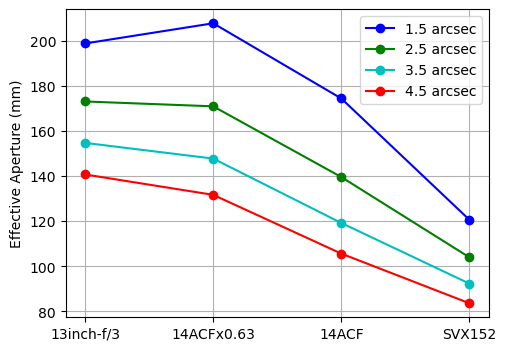

In [6]:
plt.figure(figsize=(12,4))
colors = ['b', 'g', 'c', 'r']
plt.subplot(1,2,1)
for i,s in enumerate(seeing):
    throughputs = []
    effective_areas = []
    for j,tel in enumerate(telescopes):
        throughput, profile = slit_throughput(s, tel, alpy600, IMX183)
        throughputs.append(throughput)
        effective_areas.append(throughput*tel.area)
    effective_apertures = [((area/np.pi)**0.5).to(u.mm).value for area in effective_areas]
    plt.plot(effective_apertures, f'{colors[i]}o-', label=f'{s:.1f} arcsec')
plt.legend(loc='best')
plt.gca().set_xticks([i for i in range(len(telescopes))])
plt.gca().set_xticklabels(telescopes)
plt.grid()
plt.ylabel('Effective Aperture (mm)')
plt.show()